In [ ]:
import json
import random
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
from google.colab import drive
from IPython.display import display

#! Reproducibility and existing project folders
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

drive.mount("/content/drive")
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")
DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
BASELINE_DIR = TASK_ROOT / "results/clean_baseline"
COLOR_DIR = TASK_ROOT / "results/color_bias"
CUE_DIR = TASK_ROOT / "results/shape_texture"
TRANSLATION_DIR = TASK_ROOT / "results/translation"
PATCH_DIR = TASK_ROOT / "results/patch_shuffle"
TRANS_FEATURE_DIR = FEATURE_DIR / "translation"
PATCH_FEATURE_DIR = FEATURE_DIR / "patch_shuffle"
REP_DIR = TASK_ROOT / "results/representation_analysis"

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]
MODEL_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}
VISUAL_TRANSLATION = "shift32_right"

#! Restore the exact 500-image reference from Part C
with np.load(DATA_PATH, allow_pickle=False) as data:
    test_labels = data["test_labels"].astype(np.int64)
    test_indices = data["test_indices"].astype(np.int64)
    CLASS_NAMES = data["class_names"].tolist()

baseline_ids = np.load(BASELINE_DIR / "clean_image_ids.npy", allow_pickle=False)

if (len(test_indices) != 500 or len(CLASS_NAMES) != 10
    or not np.array_equal(baseline_ids, test_indices)):
    raise ValueError("Clean subset differs from Part C; do not continue.")

#! Restore the frozen cue selection and official translation settings
selected = pd.read_csv(CUE_DIR / "selected_manifest.csv", keep_default_na=False)
translation_manifest = pd.read_csv(TRANSLATION_DIR / "transformation_manifest.csv")
shift_rows = translation_manifest.loc[translation_manifest.displacement > 0].to_dict("records")

if (len(selected) != 200 or selected.candidate_id.duplicated().any()
    or selected.content_id.duplicated().any()):
    raise ValueError("Expected 200 distinct, selected cue-conflict content images.")

content_positions = selected.content_pos.to_numpy(dtype=np.int64)
content_ids = selected.content_id.to_numpy(dtype=np.int64)
content_labels = selected.content_label.to_numpy(dtype=np.int64)

if (not np.array_equal(test_indices[content_positions], content_ids)
    or not np.array_equal(test_labels[content_positions], content_labels)):
    raise ValueError("Cue-conflict content IDs do not match clean features.")

if (len(shift_rows) != 12
    or VISUAL_TRANSLATION not in set(translation_manifest.condition)):
    raise ValueError("Expected twelve saved shifts and the chosen 32px right shift.")

#! Stop early with an exact inventory instead of silently re-extracting features
required = ([FEATURE_DIR / f"{m}_test.pt" for m in MODEL_NAMES]
            + [FEATURE_DIR / f"{m}_grayscale.pt" for m in MODEL_NAMES]
            + [FEATURE_DIR / f"{m}_cue_conflict.pt" for m in MODEL_NAMES]
            + [PATCH_FEATURE_DIR / f"{m}_patch_shuffle.pt" for m in MODEL_NAMES]
            + [TRANS_FEATURE_DIR / f"{m}_{row['condition']}.pt"
               for m in MODEL_NAMES for row in shift_rows]
            + [BASELINE_DIR / f"{m}_clean_predictions.npz"
               for m in MODEL_NAMES + ["clip_zero_shot"]]
            + [COLOR_DIR / f"{m}_grayscale_predictions.npz"
               for m in MODEL_NAMES + ["clip_zero_shot"]]
            + [CUE_DIR / f"{m}_cue_predictions.npz"
               for m in MODEL_NAMES + ["clip_zero_shot"]]
            + [PATCH_DIR / f"{m}_patch_predictions.npz"
               for m in MODEL_NAMES + ["clip_zero_shot"]]
            + [TRANSLATION_DIR / f"{m}_{row['condition']}_predictions.npz"
               for m in MODEL_NAMES + ["clip_zero_shot"] for row in shift_rows])

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError("Finish the missing previous experiments first:\n" + "\n".join(missing))

REP_DIR.mkdir(parents=True, exist_ok=True)
print("Prerequisites verified:", len(required), "files")
print("Frozen visualization images:", len(content_ids))
print("Device: CPU — no backbone inference")
print("Output folder:", REP_DIR)

Mounted at /content/drive
Prerequisites verified: 112 files
Frozen visualization images: 200
Device: CPU — no backbone inference
Output folder: /content/drive/MyDrive/pa1-beyond-iid/task1/results/representation_analysis


In [ ]:
#! Save the settings before viewing stability values or projections
plan = {
    "task": "Task 1 Part H - Representation Analysis",
    "seed": SEED,
    "backbones": MODEL_NAMES,
    "cosine_metric": "mean of individual paired cosines (not cosine of averaged vectors)",
    "interventions": ["grayscale", "cue_conflict", "translation", "patch_shuffle"],
    "translation_displacements": [8, 16, 32],
    "translation_directions": sorted(translation_manifest.loc[
        translation_manifest.displacement > 0, "direction"].unique().tolist()),
    "translation_summary": "mean over each of four directions at the same displacement",
    "visual_translation": VISUAL_TRANSLATION,
    "visual_subset": "exactly 200 content IDs, in frozen Part E selected_manifest.csv order",
    "visual_conditions": ["clean", "grayscale", "cue_conflict", VISUAL_TRANSLATION, "patch_shuffle"],
    "projection": "PCA to 50 dimensions followed by one jointly fitted t-SNE per backbone",
    "pca_components": 50,
    "tsne_perplexity": 30,
    "tsne_iterations": 1000,
    "tsne_random_state": SEED,
    "tsne_init": "pca",
    "tsne_learning_rate": "auto",
    "tsne_input": "unit-normalized embeddings, PCA fitted to combined five-condition subset",
    "hypothesis": "Representation changes and prediction changes need not coincide."
}
config_path = REP_DIR / "experiment_config.json"

if config_path.exists():
    if json.loads(config_path.read_text()) != plan:
        raise ValueError("Saved Part H settings differ; inspect before overwriting.")
else:
    config_path.write_text(json.dumps(plan, indent=2))


def read_features(path, expected_ids, feature_dim, id_key="indices"):
    saved = torch.load(path, map_location="cpu", weights_only=True)
    features = saved["features"].float()
    ids = saved[id_key]
    ids = ids.numpy() if isinstance(ids, torch.Tensor) else np.asarray(ids)
    if (features.shape != (len(expected_ids), feature_dim)
        or not np.array_equal(ids, expected_ids)
        or not torch.isfinite(features).all()):
        raise ValueError(f"Invalid or misordered feature cache: {path}")
    if torch.any(torch.linalg.vector_norm(features, dim=1) <= 1e-12):
        raise ValueError(f"Zero-norm feature detected: {path}")
    return features


def read_predictions(path, expected_ids, id_key="image_ids"):
    with np.load(path, allow_pickle=False) as saved:
        ids = saved[id_key]
        predictions = saved["y_pred"].astype(np.int64)
    if not np.array_equal(ids, expected_ids) or len(predictions) != len(expected_ids):
        raise ValueError(f"Invalid or misordered predictions: {path}")
    return predictions


def paired_cosine(clean, transformed):
    if clean.shape != transformed.shape:
        raise ValueError("Paired embeddings have different shapes.")
    values = F.cosine_similarity(clean, transformed, dim=1, eps=1e-12).numpy()
    if not np.isfinite(values).all():
        raise ValueError("Non-finite cosine similarity.")
    return np.clip(values, -1.0, 1.0)


#! A cue-conflict embedding must be matched to its own original content image
cue_ids = selected.candidate_id.astype(str).tolist()
cue_image_ids = selected.content_id.to_numpy(dtype=np.int64)

print("Frozen analysis settings:", config_path)
print("Cue-conflict alignment uses original content image IDs.")

Frozen analysis settings: /content/drive/MyDrive/pa1-beyond-iid/task1/results/representation_analysis/experiment_config.json
Cue-conflict alignment uses original content image IDs.


In [ ]:
#! Save paired cosines and a prediction-level comparison for each intervention
pair_rows = []
condition_rows = []
change_rows = []

for backbone in MODEL_NAMES:
    print("Analyzing:", backbone)
    dim = MODEL_DIMS[backbone]
    clean_features = read_features(FEATURE_DIR / f"{backbone}_test.pt", test_indices, dim)
    decision_models = ([backbone, "clip_zero_shot"] if backbone == "clip_b32"
                       else [backbone])

    def record_condition(name, transformed, original_positions, candidate_ids=None,
                         displacement=0, direction="none"):
        original_ids = test_indices[original_positions]
        cosines = paired_cosine(clean_features[original_positions], transformed)
        condition_rows.append({
            "backbone": backbone, "condition": name, "displacement": displacement,
            "direction": direction, "n_pairs": len(cosines),
            "mean_cosine_stability": float(cosines.mean()),
            "std_cosine": float(cosines.std()),
            "median_cosine": float(np.median(cosines))
        })

        for i, value in enumerate(cosines):
            pair_rows.append({
                "backbone": backbone, "condition": name,
                "original_image_id": int(original_ids[i]),
                "candidate_id": (candidate_ids[i] if candidate_ids is not None else ""),
                "true_class": CLASS_NAMES[int(test_labels[original_positions[i]])],
                "displacement": displacement, "direction": direction,
                "cosine_stability": float(value)
            })

        for decision_model in decision_models:
            clean_pred = read_predictions(
                BASELINE_DIR / f"{decision_model}_clean_predictions.npz", test_indices
            )[original_positions]

            if name == "cue_conflict":
                prediction_path = CUE_DIR / f"{decision_model}_cue_predictions.npz"
                transformed_pred = read_predictions(prediction_path, np.asarray(cue_ids), "candidate_ids")
                with np.load(prediction_path, allow_pickle=False) as saved:
                    if not np.array_equal(saved["content_ids"], original_ids):
                        raise ValueError(f"Cue predictions misaligned: {decision_model}")
            elif name == "grayscale":
                transformed_pred = read_predictions(
                    COLOR_DIR / f"{decision_model}_grayscale_predictions.npz", test_indices
                )
            elif name == "patch_shuffle":
                transformed_pred = read_predictions(
                    PATCH_DIR / f"{decision_model}_patch_predictions.npz", test_indices
                )
            else:
                transformed_pred = read_predictions(
                    TRANSLATION_DIR / f"{decision_model}_{name}_predictions.npz", test_indices
                )

            unchanged = clean_pred == transformed_pred

            for status, mask in (("unchanged", unchanged), ("changed", ~unchanged)):
                change_rows.append({
                    "backbone": backbone, "decision_model": decision_model,
                    "condition": name, "displacement": displacement,
                    "direction": direction, "prediction_status": status,
                    "n_pairs": int(mask.sum()),
                    "mean_cosine_stability": (float(cosines[mask].mean())
                                              if mask.any() else np.nan)
                })

    gray = read_features(FEATURE_DIR / f"{backbone}_grayscale.pt", test_indices, dim)
    record_condition("grayscale", gray, np.arange(500))
    del gray

    cue = read_features(FEATURE_DIR / f"{backbone}_cue_conflict.pt",
                        np.asarray(cue_ids), dim, id_key="candidate_ids")
    cue_saved = torch.load(FEATURE_DIR / f"{backbone}_cue_conflict.pt",
                           map_location="cpu", weights_only=True)

    if not np.array_equal(cue_saved["content_ids"].numpy(), cue_image_ids):
        raise ValueError("Cue features are aligned to the wrong clean content images.")
    record_condition("cue_conflict", cue, content_positions, cue_ids)

    del cue, cue_saved

    shuffled = read_features(PATCH_FEATURE_DIR / f"{backbone}_patch_shuffle.pt",
                             test_indices, dim)
    record_condition("patch_shuffle", shuffled, np.arange(500))

    del shuffled

    for row in shift_rows:
        features = read_features(
            TRANS_FEATURE_DIR / f"{backbone}_{row['condition']}.pt", test_indices, dim
        )
        record_condition(row["condition"], features, np.arange(500),
                         displacement=int(row["displacement"]),
                         direction=str(row["direction"]))
        del features

    del clean_features

#! Every saved statistic is traceable to individually paired rows
pairs_df = pd.DataFrame(pair_rows)
conditions_df = pd.DataFrame(condition_rows)
changes_df = pd.DataFrame(change_rows)
pairs_df.to_csv(REP_DIR / "paired_cosines.csv", index=False)
conditions_df.to_csv(REP_DIR / "per_condition.csv", index=False)
changes_df.to_csv(REP_DIR / "prediction_conditioned.csv", index=False)

print("Paired observations:", len(pairs_df))
display(conditions_df.round(4).head(15))

Analyzing: resnet50
Analyzing: vit_b16
Analyzing: clip_b32
Paired observations: 21600


,backbone,condition,displacement,direction,n_pairs,mean_cosine_stability,std_cosine,median_cosine
0,resnet50,grayscale,0,none,500,0.7884,0.0978,0.7990
1,resnet50,cue_conflict,0,none,200,0.3735,0.1635,0.3542
2,resnet50,patch_shuffle,0,none,500,0.7151,0.0737,0.7180
3,resnet50,shift8_right,8,right,500,0.9656,0.0218,0.9716
4,resnet50,shift8_left,8,left,500,0.9738,0.0139,0.9768
5,resnet50,shift8_down,8,down,500,0.9655,0.0185,0.9694
6,resnet50,shift8_up,8,up,500,0.9692,0.0144,0.9720
7,resnet50,shift16_right,16,right,500,0.9440,0.0360,0.9550
8,resnet50,shift16_left,16,left,500,0.9608,0.0222,0.9662
9,resnet50,shift16_down,16,down,500,0.9493,0.0302,0.9561


In [ ]:
#! Core four-intervention table, with one explicit translation setting
main_rows = []
translation_rows = []

for backbone in MODEL_NAMES:
    current = conditions_df.loc[conditions_df.backbone == backbone]

    for condition in ("grayscale", "cue_conflict", "patch_shuffle"):
        row = current.loc[current.condition == condition].iloc[0]
        main_rows.append({
            "backbone": backbone, "intervention": condition,
            "n_pairs": int(row.n_pairs),
            "mean_cosine_stability": float(row.mean_cosine_stability)
        })

    shifts = current.loc[current.displacement > 0]

    for pixels, group in shifts.groupby("displacement"):
        if len(group) != 4:
            raise ValueError("Expected four translation directions at each displacement.")
        translation_rows.append({
            "backbone": backbone, "displacement": int(pixels),
            "directions": len(group), "total_pairs": int(group.n_pairs.sum()),
            "mean_cosine_stability": float(group.mean_cosine_stability.mean())
        })
        if pixels == 32:
            main_rows.append({
                "backbone": backbone, "intervention": "translation_32px_mean4",
                "n_pairs": int(group.n_pairs.sum()),
                "mean_cosine_stability": float(group.mean_cosine_stability.mean())
            })

main_df = pd.DataFrame(main_rows)
translation_df = pd.DataFrame(translation_rows)
classwise_df = (pairs_df.groupby(["backbone", "condition", "true_class"], as_index=False)
                .agg(n_pairs=("cosine_stability", "size"),
                     mean_cosine_stability=("cosine_stability", "mean")))

main_df.to_csv(REP_DIR / "summary.csv", index=False)
translation_df.to_csv(REP_DIR / "translation_by_displacement.csv", index=False)
classwise_df.to_csv(REP_DIR / "per_class.csv", index=False)

with open(REP_DIR / "summary.json", "w") as f:
    json.dump({"seed": SEED, "results": main_rows,
               "translation": translation_rows}, f, indent=2)

print("Main representation-stability table:")
display(main_df.round(4))
print("Direction-averaged translation stability:")
display(translation_df.round(4))

Main representation-stability table:


,backbone,intervention,n_pairs,mean_cosine_stability
0,resnet50,grayscale,500,0.7884
1,resnet50,cue_conflict,200,0.3735
2,resnet50,patch_shuffle,500,0.7151
3,resnet50,translation_32px_mean4,2000,0.9327
4,vit_b16,grayscale,500,0.7393
5,vit_b16,cue_conflict,200,0.4059
6,vit_b16,patch_shuffle,500,0.6532
7,vit_b16,translation_32px_mean4,2000,0.9418
8,clip_b32,grayscale,500,0.8935
9,clip_b32,cue_conflict,200,0.7399


Direction-averaged translation stability:


,backbone,displacement,directions,total_pairs,mean_cosine_stability
0,resnet50,8,4,2000,0.9685
1,resnet50,16,4,2000,0.9525
2,resnet50,32,4,2000,0.9327
3,vit_b16,8,4,2000,0.9471
4,vit_b16,16,4,2000,0.9743
5,vit_b16,32,4,2000,0.9418
6,clip_b32,8,4,2000,0.9811
7,clip_b32,16,4,2000,0.9680
8,clip_b32,32,4,2000,0.9691


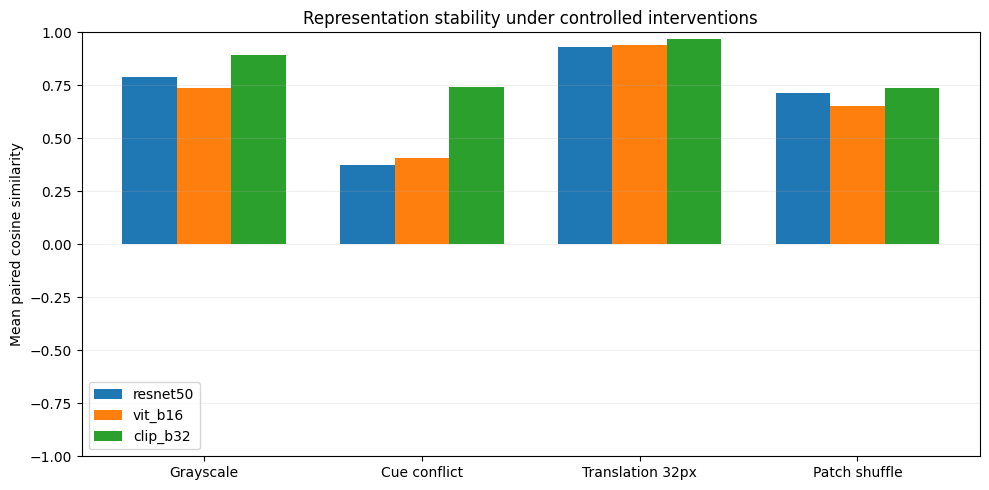

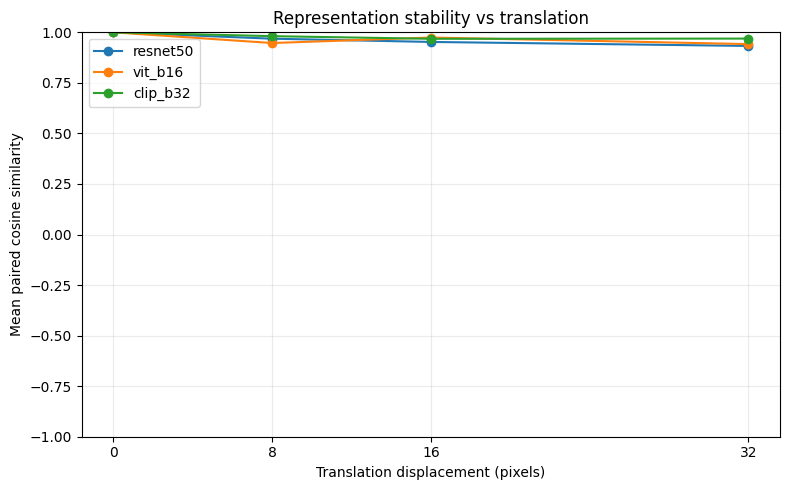

Two quantitative plots saved.


In [ ]:
#! Representation stability for all required interventions
order = ["grayscale", "cue_conflict", "translation_32px_mean4", "patch_shuffle"]
labels = ["Grayscale", "Cue conflict", "Translation 32px", "Patch shuffle"]
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25

for j, backbone in enumerate(MODEL_NAMES):
    values = [main_df.loc[(main_df.backbone == backbone)
                          & (main_df.intervention == condition),
                          "mean_cosine_stability"].iloc[0] for condition in order]
    ax.bar(x + (j - 1) * width, values, width, label=backbone)

ax.set_xticks(x, labels)
ax.set_ylabel("Mean paired cosine similarity")
ax.set_ylim(-1.0, 1.0)
ax.set_title("Representation stability under controlled interventions")
ax.legend()
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
fig.savefig(REP_DIR / "representation_stability.png", dpi=300, bbox_inches="tight")

plt.show()

#! Translation stability averages four cardinal directions at each displacement
fig, ax = plt.subplots(figsize=(8, 5))
for backbone in MODEL_NAMES:
    subset = translation_df.loc[translation_df.backbone == backbone].sort_values("displacement")
    ax.plot([0] + subset.displacement.tolist(),
            [1.0] + subset.mean_cosine_stability.tolist(), marker="o", label=backbone)

ax.set_xticks([0, 8, 16, 32])
ax.set_xlabel("Translation displacement (pixels)")
ax.set_ylabel("Mean paired cosine similarity")
ax.set_ylim(-1.0, 1.0)
ax.set_title("Representation stability vs translation")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(REP_DIR / "translation_representation_curve.png", dpi=300, bbox_inches="tight")

plt.show()

print("Two quantitative plots saved.")

In [ ]:
#! Fixed 200-item visualization subset: same content IDs in every condition
VIS_CONDITIONS = ["clean", "grayscale", "cue_conflict", VISUAL_TRANSLATION, "patch_shuffle"]
vis_labels = content_labels.copy()


def make_visual_feature_table(backbone):
    dim = MODEL_DIMS[backbone]
    clean = read_features(FEATURE_DIR / f"{backbone}_test.pt", test_indices, dim)
    gray = read_features(FEATURE_DIR / f"{backbone}_grayscale.pt", test_indices, dim)
    cue = read_features(FEATURE_DIR / f"{backbone}_cue_conflict.pt",
                        np.asarray(cue_ids), dim, id_key="candidate_ids")

    shifted = read_features(TRANS_FEATURE_DIR / f"{backbone}_{VISUAL_TRANSLATION}.pt",
                            test_indices, dim)
    shuffled = read_features(PATCH_FEATURE_DIR / f"{backbone}_patch_shuffle.pt",
                             test_indices, dim)

    groups = [clean[content_positions], gray[content_positions], cue,
              shifted[content_positions], shuffled[content_positions]]

    combined = torch.cat(groups, dim=0)
    combined = F.normalize(combined, p=2, dim=1).numpy().astype(np.float32)
    metadata_rows = []

    for name in VIS_CONDITIONS:
        for j, image_id in enumerate(content_ids):
            metadata_rows.append({
                "condition": name, "original_image_id": int(image_id),
                "candidate_id": cue_ids[j], "class_label": int(vis_labels[j]),
                "class_name": CLASS_NAMES[int(vis_labels[j])], "sample_order": j
            })

    if combined.shape != (1000, dim):
        raise ValueError(f"Incorrect visualization batch for {backbone}.")
    return combined, pd.DataFrame(metadata_rows)


print("Visualization subset: 200 originals × 5 conditions = 1,000 points/backbone")
print("Translation visualization:", VISUAL_TRANSLATION)

Visualization subset: 200 originals × 5 conditions = 1,000 points/backbone
Translation visualization: shift32_right


In [ ]:
#! One PCA + one t-SNE for all five conditions, separately for each backbone
for backbone in MODEL_NAMES:
    output_path = REP_DIR / f"{backbone}_tsne_coordinates.csv"

    if output_path.exists():
        old = pd.read_csv(output_path)

        if (len(old) != 1000 or old.condition.tolist() !=
            [name for name in VIS_CONDITIONS for _ in range(200)]
            or not np.array_equal(old.original_image_id.to_numpy(),
                                  np.tile(content_ids, len(VIS_CONDITIONS)))):
            raise ValueError(f"Existing projection has a different sample definition: {output_path}")

        print("Reusing:", output_path.name)
        continue

    combined, metadata = make_visual_feature_table(backbone)
    reduced = PCA(n_components=50, random_state=SEED).fit_transform(combined)

    #! max_iter was named n_iter in older versions of scikit-learn
    options = dict(n_components=2, perplexity=30, random_state=SEED,
                   init="pca", learning_rate="auto")

    iterations = "max_iter" if "max_iter" in inspect.signature(TSNE).parameters else "n_iter"
    options[iterations] = 1000
    coordinates = TSNE(**options).fit_transform(reduced)

    metadata["x"] = coordinates[:, 0]
    metadata["y"] = coordinates[:, 1]
    metadata.to_csv(output_path, index=False)

    print("Saved:", output_path.name, "points:", len(metadata))
    del combined, reduced, coordinates, metadata

print("All three joint projections are saved.")

Saved: resnet50_tsne_coordinates.csv points: 1000
Saved: vit_b16_tsne_coordinates.csv points: 1000
Saved: clip_b32_tsne_coordinates.csv points: 1000
All three joint projections are saved.


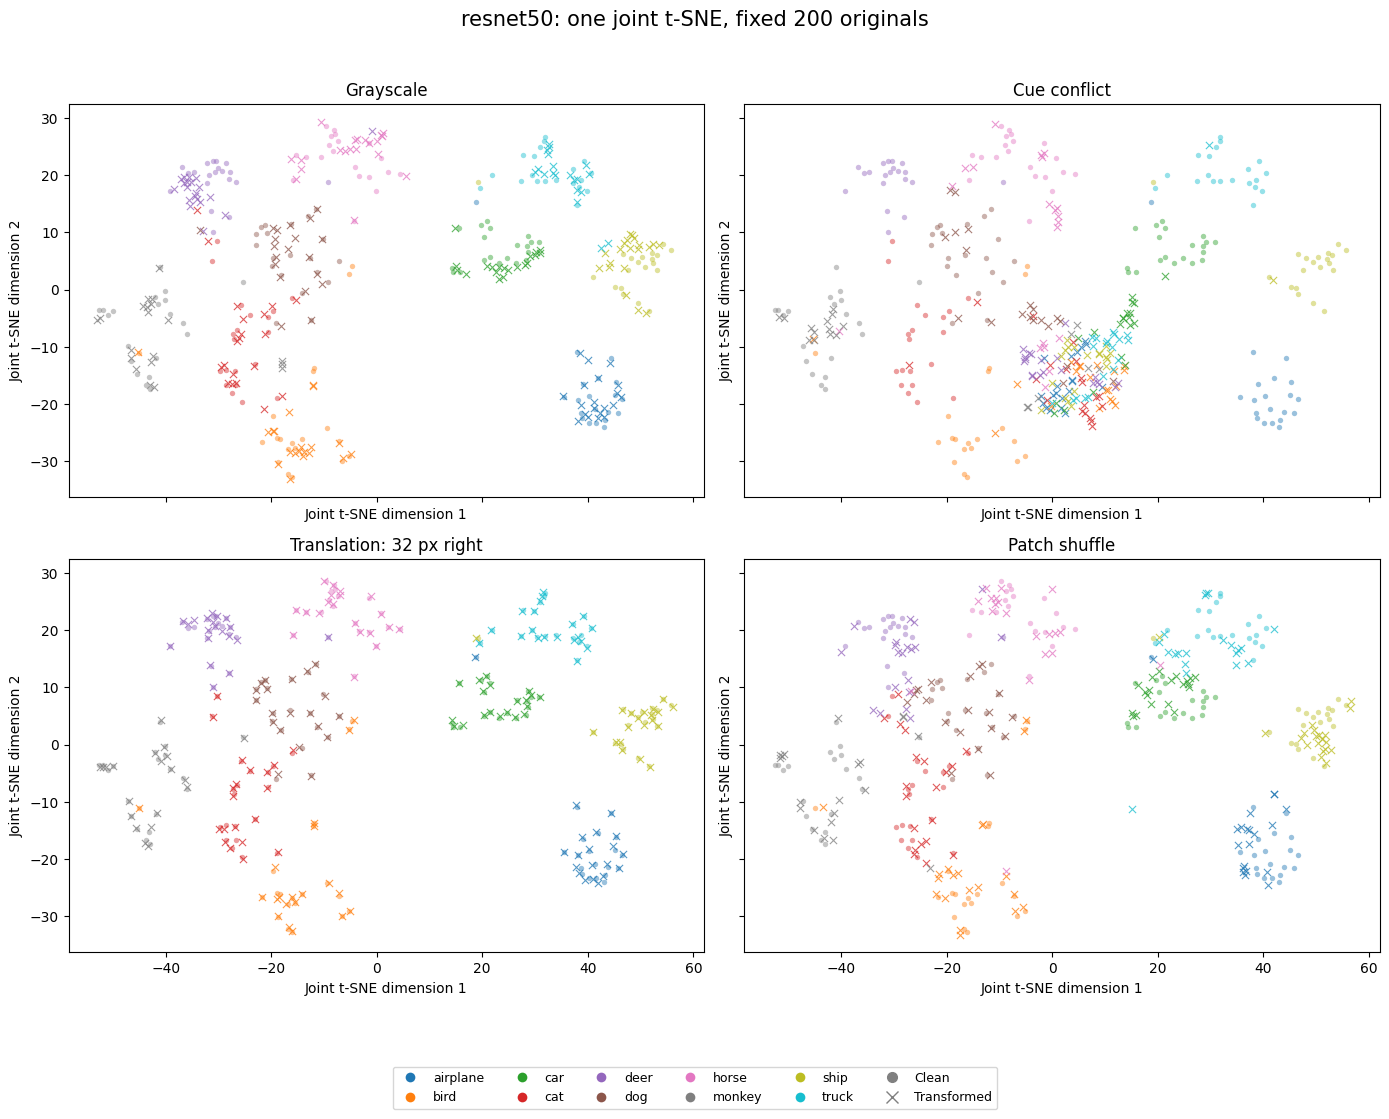

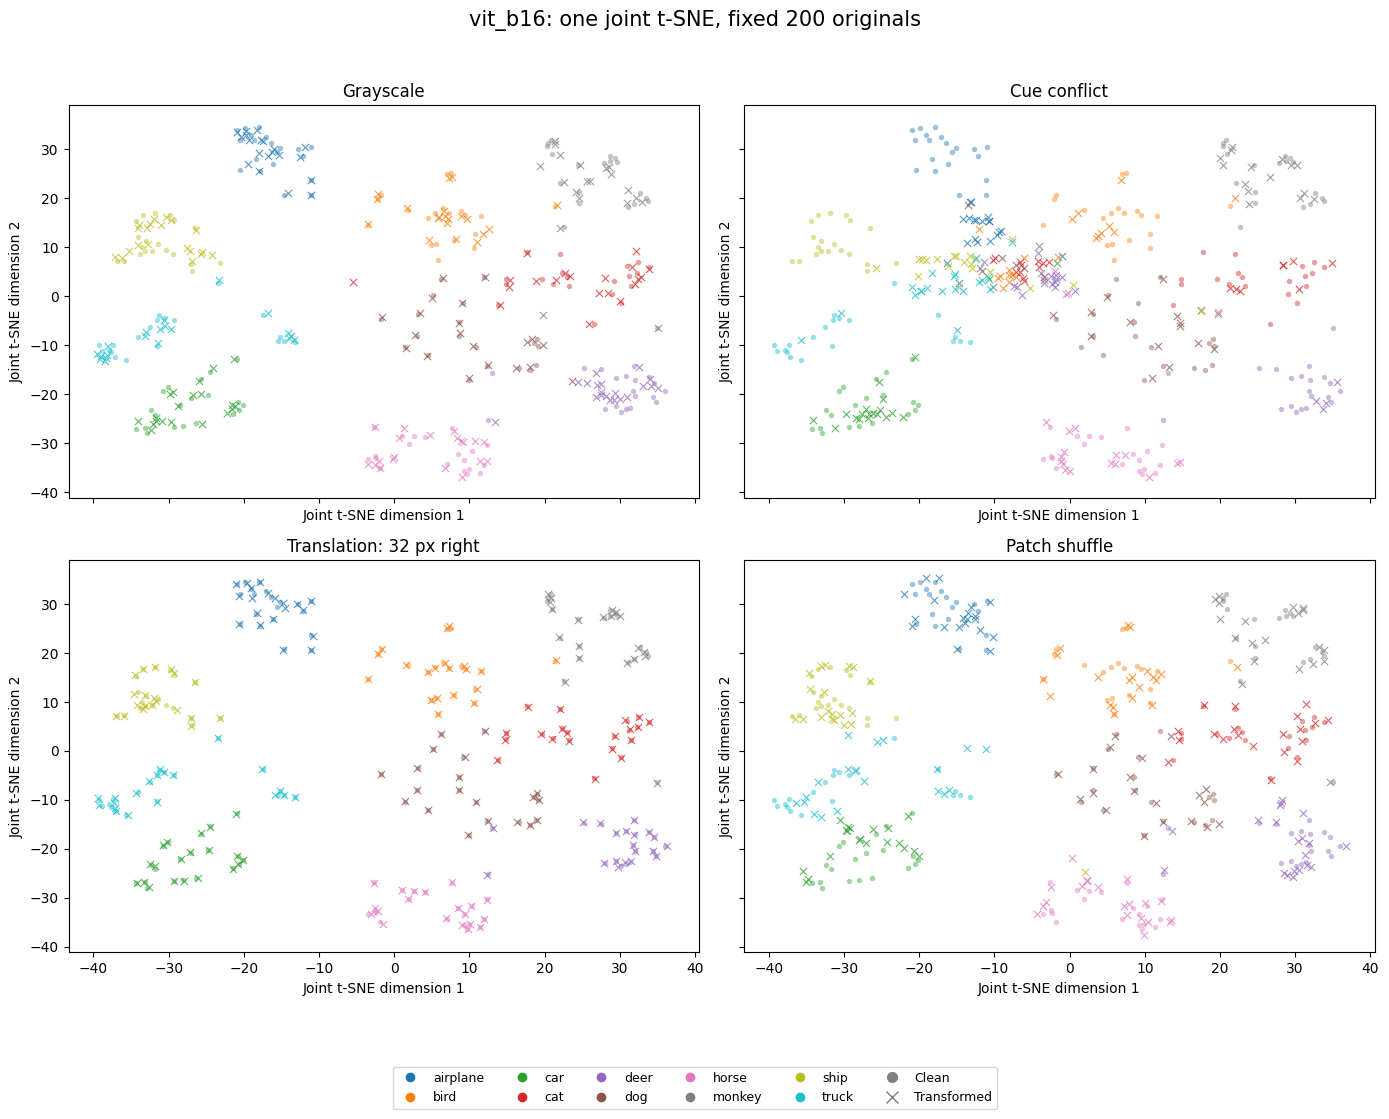

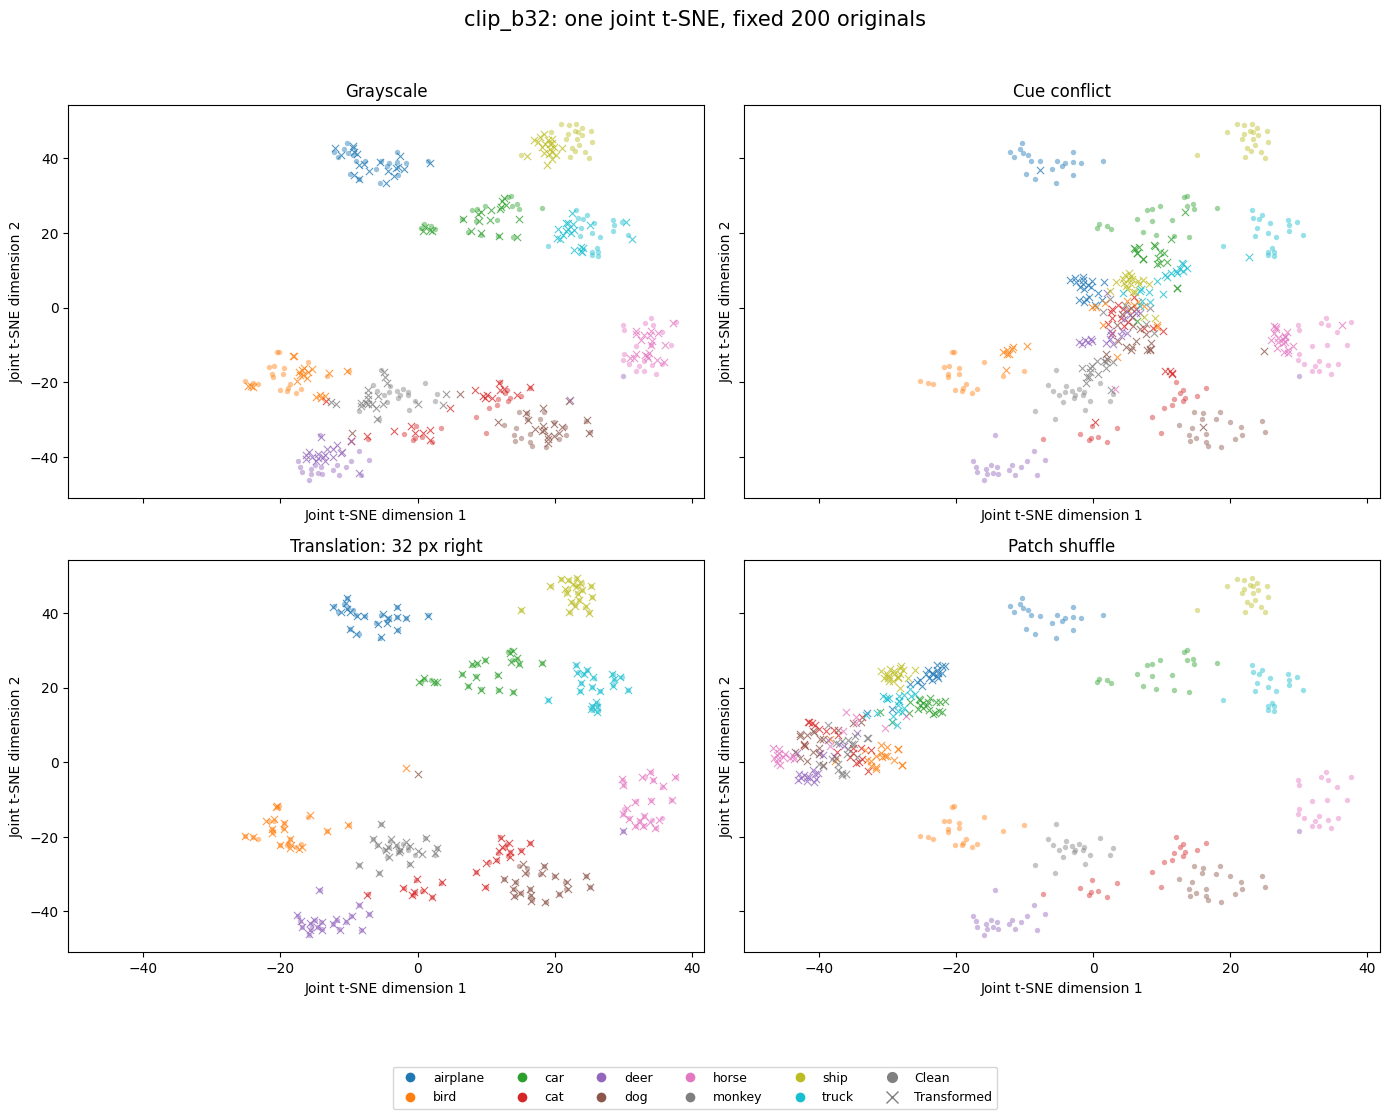

Saved three joint t-SNE figures and coordinate CSVs.


In [ ]:
#! Plot a single consistent two-dimensional projection per backbone
palette = plt.get_cmap("tab10")

condition_titles = {
    "grayscale": "Grayscale", "cue_conflict": "Cue conflict",
    VISUAL_TRANSLATION: "Translation: 32 px right", "patch_shuffle": "Patch shuffle"
}

for backbone in MODEL_NAMES:
    coords = pd.read_csv(REP_DIR / f"{backbone}_tsne_coordinates.csv")
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)

    for ax, condition in zip(axes.flat, condition_titles):
        clean = coords.loc[coords.condition == "clean"]
        transformed = coords.loc[coords.condition == condition]

        for class_id in range(10):
            a = clean.loc[clean.class_label == class_id]
            b = transformed.loc[transformed.class_label == class_id]
            color = palette(class_id)
            ax.scatter(a.x, a.y, c=[color], s=15, marker="o", alpha=0.45,
                       linewidths=0, rasterized=True)
            ax.scatter(b.x, b.y, c=[color], s=27, marker="x", alpha=0.75,
                       linewidths=0.8, rasterized=True)

        ax.set_title(condition_titles[condition])
        ax.set_xlabel("Joint t-SNE dimension 1")
        ax.set_ylabel("Joint t-SNE dimension 2")

    class_handles = [Line2D([0], [0], marker="o", color="none",
                            markerfacecolor=palette(i), markeredgecolor="none",
                            label=CLASS_NAMES[i], markersize=7) for i in range(10)]

    state_handles = [Line2D([0], [0], marker="o", linestyle="none", color="gray",
                            label="Clean", markersize=7),
                     Line2D([0], [0], marker="x", linestyle="none", color="gray",
                            label="Transformed", markersize=8)]

    fig.legend(handles=class_handles + state_handles, loc="lower center",
               ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.025))

    fig.suptitle(f"{backbone}: one joint t-SNE, fixed 200 originals", fontsize=15)
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    fig.savefig(REP_DIR / f"{backbone}_joint_tsne.png", dpi=260, bbox_inches="tight")

    plt.show()

print("Saved three joint t-SNE figures and coordinate CSVs.")

In [ ]:
#! Read-only validation of saved Part H outputs
required_results = [
    "experiment_config.json", "paired_cosines.csv", "per_condition.csv",
    "prediction_conditioned.csv", "summary.csv", "summary.json", "per_class.csv",
    "translation_by_displacement.csv", "representation_stability.png",
    "translation_representation_curve.png"
]

for backbone in MODEL_NAMES:
    required_results += [f"{backbone}_tsne_coordinates.csv", f"{backbone}_joint_tsne.png"]

missing = [name for name in required_results if not (REP_DIR / name).is_file()]

if missing:
    raise FileNotFoundError(f"Missing Part H outputs: {missing}")

saved_pairs = pd.read_csv(REP_DIR / "paired_cosines.csv")
saved_condition = pd.read_csv(REP_DIR / "per_condition.csv")
saved_main = pd.read_csv(REP_DIR / "summary.csv")

if len(saved_main) != 12 or len(saved_condition) != 45:
    raise ValueError("Expected 4 interventions × 3 backbones and 15 conditions × 3 backbones.")

for backbone in MODEL_NAMES:
    rows = saved_pairs.loc[saved_pairs.backbone == backbone]

    for name, group in rows.groupby("condition"):
        expected = saved_condition.loc[(saved_condition.backbone == backbone)
                                       & (saved_condition.condition == name)]

        if len(expected) != 1 or not np.isclose(
                group.cosine_stability.mean(), expected.mean_cosine_stability.iloc[0], atol=1e-6):
            raise ValueError(f"Saved cosine average disagrees with individual values: {backbone}/{name}")

    table = pd.read_csv(REP_DIR / f"{backbone}_tsne_coordinates.csv")

    if (len(table) != 1000 or not np.isfinite(table[["x", "y"]].to_numpy()).all()):
        raise ValueError(f"Invalid joint projection: {backbone}")

    for condition in VIS_CONDITIONS:
        subset = table.loc[table.condition == condition]
        if not np.array_equal(subset.original_image_id.to_numpy(), content_ids):
            raise ValueError(f"Projection sample/order changed: {backbone}/{condition}")

    print(backbone, "cosines and joint t-SNE verified")

print("\nPART H COMPLETE —", len(required_results), "output files verified")
print("Saved in:", REP_DIR)

display(saved_main.round(4))

resnet50 cosines and joint t-SNE verified
vit_b16 cosines and joint t-SNE verified
clip_b32 cosines and joint t-SNE verified

PART H COMPLETE — 16 output files verified
Saved in: /content/drive/MyDrive/pa1-beyond-iid/task1/results/representation_analysis


,backbone,intervention,n_pairs,mean_cosine_stability
0,resnet50,grayscale,500,0.7884
1,resnet50,cue_conflict,200,0.3735
2,resnet50,patch_shuffle,500,0.7151
3,resnet50,translation_32px_mean4,2000,0.9327
4,vit_b16,grayscale,500,0.7393
5,vit_b16,cue_conflict,200,0.4059
6,vit_b16,patch_shuffle,500,0.6532
7,vit_b16,translation_32px_mean4,2000,0.9418
8,clip_b32,grayscale,500,0.8935
9,clip_b32,cue_conflict,200,0.7399
